<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/10.%20%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%20%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%20YOLOv9%20%D0%B4%D0%BB%D1%8F%20%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5%20%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%20%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%86%D0%B8%D0%B8%20%D0%B8%20%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_YOLOv12_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%86%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv26 относительно предыдущих версий?**

**Принципиальные отличия YOLOv26 от предыдущих версий:**

1. **Сквозной вывод без NMS (End-to-End):** Как и в последних версиях (с v10), YOLOv26 работает без этапа постобработки NMS, генерируя прогнозы напрямую. Это снижает задержку и делает вывод в реальном времени быстрее и стабильнее.
2. **Удаление DFL:** Модуль Distribution Focal Loss (DFL) был удален для упрощения инференса и расширения поддержки периферийных Edge и IoT устройств с низким энергопотреблением.
3. **Новый оптимизатор MuSGD:** Представлен гибридный оптимизатор (SGD + Muon), заимствованный из подходов обучения LLM (Kimi K2). Он обеспечивает более стабильное обучение и быструю сходимость.
4. **Улучшение потерь (ProgLoss + STAL):** Новые функции лосса колоссально улучшили распознавание *мелких объектов*, что критически важно в аэрофотосъемке.
5. **Оптимизация производительности:** Вывод на CPU стал до 43% быстрее за счет оптимизации архитектуры под Edge-вычисления.
6. **Улучшения в смежных задачах:** Интеграция RLE для более точной оценки поз (Pose Estimation), введение потерь семантической сегментации для повышения качества масок и специализированные функции потерь для OBB (Oriented Bounding Boxes).

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [1]:
# 1. Установка необходимых библиотек
!pip install -q ultralytics roboflow

import locale

locale.getpreferredencoding = lambda: "UTF-8"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.8 MB/s eta 0:00:00


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="fhRkq4UGLeKk6BeMAG8h")
project = rf.workspace("roboflow-58fyf").project("rock-paper-scissors-sxsw")
version = project.version(14)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to rock-paper-scissors-14 in yolo26:: 100%|██████████| 14682/14682 [00:01<00:00, 8165.38it/s] 


In [6]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")


results = model.train(data="coco128.yaml", epochs=100, imgsz=640)

metrics = model.val()
print("Mean Average Precision (mAP50-95):", metrics.box.map)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

In [7]:
model.predict(source="https://ultralytics.com/images/bus.jpg", save=True, imgsz=640)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 11.7ms
Speed: 3.4ms preprocess, 11.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

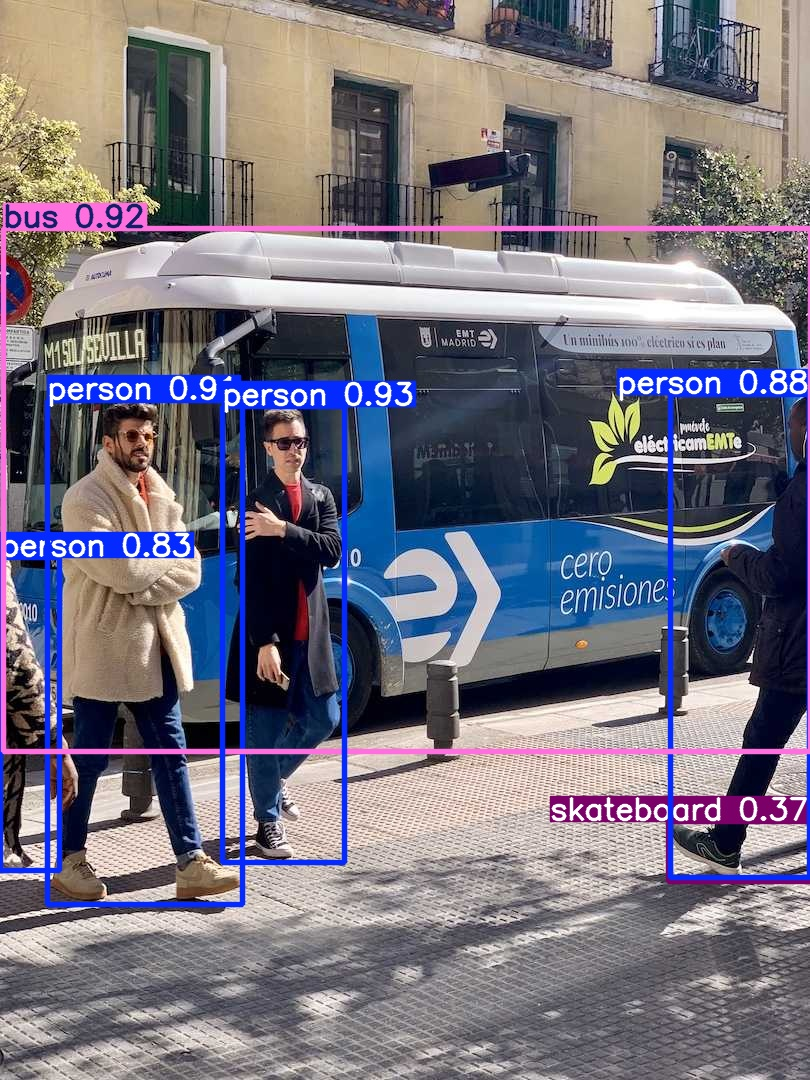

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [11]:
import gc

del model
del results
del metrics
gc.collect()

22224

In [8]:

rf = Roboflow(api_key="fhRkq4UGLeKk6BeMAG8h")
project = rf.workspace("systemmonitoring").project("task9-tslhp")
version = project.version(1)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to task9-1 in yolo26:: 100%|██████████| 937/937 [00:00<00:00, 5900.54it/s]


In [12]:
# Инициализация новой модели YOLO
# Если хотите дообучить (Transfer Learning) предыдущую модель, подставьте путь к её весам:
# custom_model = YOLO("runs/detect/train/weights/best.pt")
custom_model = YOLO("yolo26n.pt")


results_custom = custom_model.train(data="/content/task9-1/data.yaml", epochs=100, imgsz=640)

# Вывод метрик валидации
metrics_custom = custom_model.val()
print("Метрики вашего кастомного датасета:")
print("mAP50-95:", metrics_custom.box.map)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/task9-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,


image 1/1 /content/task9-1/valid/images/IMG_7079_MOV-17_jpg.rf.af2c242f40582b5ec1c87016e25493fa.jpg: 640x640 1 Rock, 20.2ms
Speed: 3.0ms preprocess, 20.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


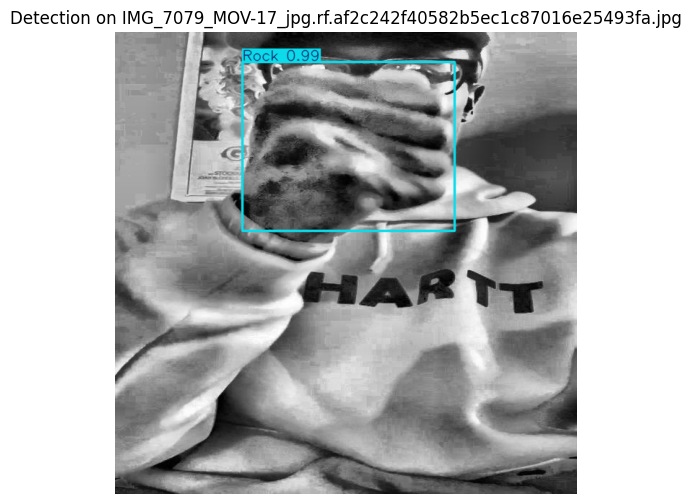


image 1/1 /content/task9-1/valid/images/0098_png.rf.bab1b58da1c206208ea2f000de3fe58f.jpg: 640x640 2 Papers, 1 Rock, 24.5ms
Speed: 2.7ms preprocess, 24.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


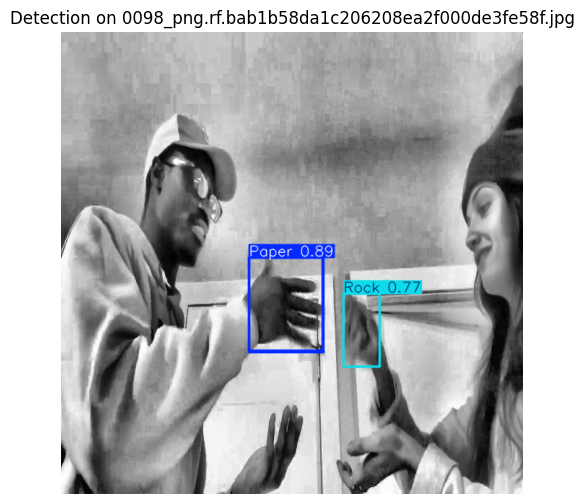


image 1/1 /content/task9-1/valid/images/IMG_5636_MOV-53_jpg.rf.eaeefedc51cffd22f820f73b5afec297.jpg: 640x640 1 Rock, 17.1ms
Speed: 3.6ms preprocess, 17.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


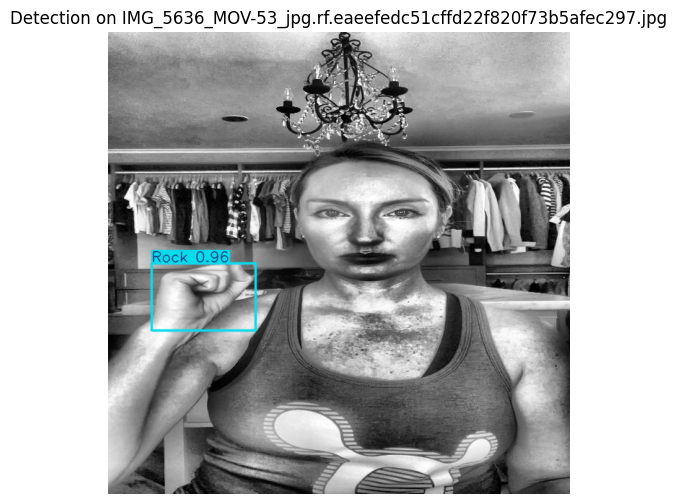

In [14]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

valid_images_path = "/content/task9-1/valid/images"
image_files = [f for f in os.listdir(valid_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Выбираем 3 случайных изображения
sample_images = random.sample(image_files, min(3, len(image_files)))

for img_name in sample_images:
    img_path = os.path.join(valid_images_path, img_name)


    results = custom_model.predict(source=img_path, conf=0.25)

    for r in results:
        im_array = r.plot()
        im = Image.fromarray(im_array[..., ::-1])
        plt.figure(figsize=(10, 6))
        plt.imshow(im)
        plt.axis('off')
        plt.title(f'Detection on {img_name}')
        plt.show()

## **Задание 4 (для магистрантов). Обучите модель YOLOv26 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

**Ссылка на датасет в среде roboflow universe:** https://universe.roboflow.com/animals-sqrdn/rsd-god

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [ ]:
# Ваш код